<a href="https://colab.research.google.com/github/Raghavganesan/enhanced-csi-estimation-uv-mimo-deep-learning/blob/Projects/FINAL_CAPSTONE_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 : GENERATING SAMPLES OF CSI MATRICES AND DISPLAYING



*   Simulate the CSI matrices using a Poisson-based fading model
*   Each CSI Matrix is a 3x3 complex-valued pair

*   Noise is added to simulate realistic LS estimation
*   Generated samples are visualized using heatmaps






✅ CSI matrices generated.
Ground Truth shape: (20000, 3, 3)
LS-Estimated shape: (20000, 3, 3)
MMSE-Estimated shape: (20000, 3, 3)
LS NMSE: 1.2109
MMSE NMSE: 1.1796


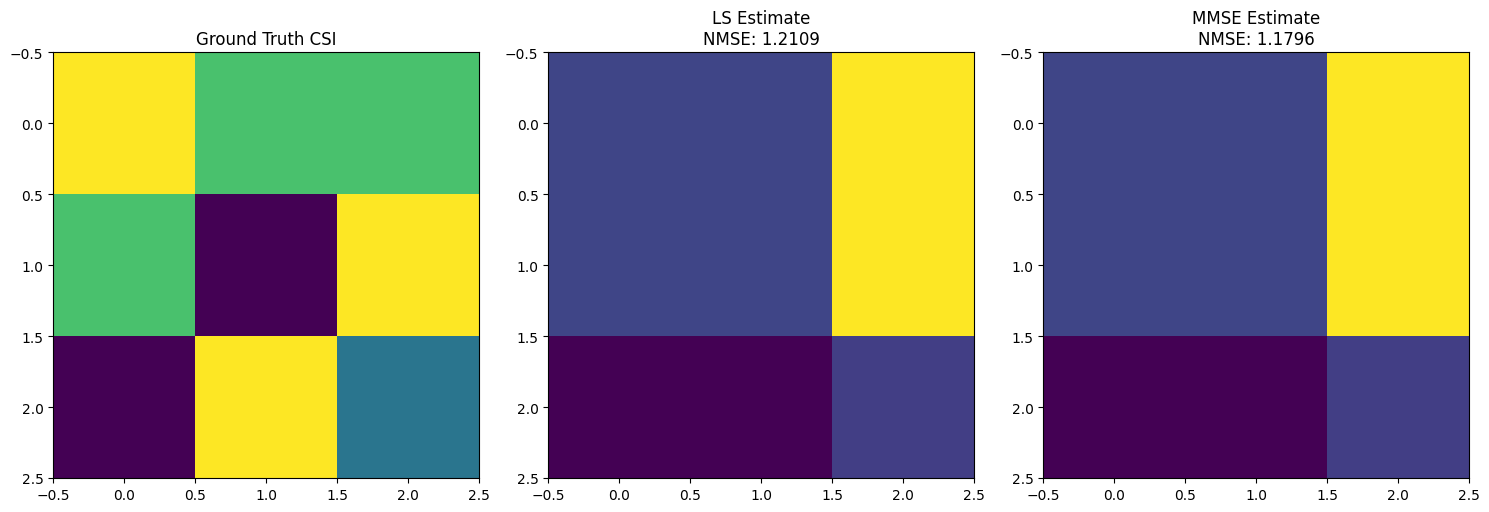

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
num_samples = 20000         # Total CSI matrices
M, N = 3, 3                 # 3x3 MIMO system
lam = 4                     # Lambda for Poisson distribution
snr_db = 10                 # SNR in dB
pilot_ratio = 0.5           # Ratio of pilot subcarriers
#PILOT SIGNALS --> known values which are put

np.random.seed(42)          # For reproducibility

# Convert SNR from dB to linear scale
snr_linear = 10**(snr_db/10)

def generate_csi_matrix_poisson(M, N, lam):
    """Simulate a CSI matrix with Poisson amplitude and random phase."""
    poisson_counts = np.random.poisson(lam, (M, N))
    amplitude = np.sqrt(poisson_counts)
    phase = 2 * np.pi * np.random.rand(M, N)
    return amplitude * np.exp(1j * phase)

# Generate Ground Truth CSI matrices
H_ground_truth = np.array([generate_csi_matrix_poisson(M, N, lam) for _ in range(num_samples)])

# Create pilot pattern and indices
pilot_pattern = np.zeros((M, N), dtype=bool)
pilot_indices = []
for i in range(0, M, max(1, int(1/pilot_ratio))):
    for j in range(0, N, max(1, int(1/pilot_ratio))):
        if i < M and j < N:
            pilot_pattern[i, j] = True
            pilot_indices.append((i, j))

# LS estimation function
def generate_ls_estimate(H_true, snr):
    batch_size = H_true.shape[0]
    H_ls = np.zeros_like(H_true)
    for b in range(batch_size):
        h_true = H_true[b]
        # Generate QPSK pilots
        X_pilot = (np.random.randint(0, 2, size=len(pilot_indices))*2-1 +
                   1j*(np.random.randint(0, 2, size=len(pilot_indices))*2-1)) / np.sqrt(2)
        pilot_values = np.array([h_true[i, j] for i, j in pilot_indices])
        Y_pilot = pilot_values * X_pilot
        # Add AWGN noise based on SNR
        noise_power = np.mean(np.abs(Y_pilot)**2) / snr
        noise = np.sqrt(noise_power/2) * (np.random.randn(len(Y_pilot)) + 1j*np.random.randn(len(Y_pilot)))
        Y_noisy = Y_pilot + noise

        H_ls_pilots = Y_noisy / X_pilot  # LS estimation at pilot positions

        # Simple nearest-neighbor interpolation
        h_ls = np.zeros((M, N), dtype=complex)
        for idx, (i, j) in enumerate(pilot_indices):
            h_ls[i, j] = H_ls_pilots[idx]
        for i in range(M):
            for j in range(N):
                if not pilot_pattern[i, j]:
                    min_dist = float('inf')-
                    nearest_val = 0
                    for p_idx, (pi, pj) in enumerate(pilot_indices):
                        dist = (i-pi)**2 + (j-pj)**2
                        if dist < min_dist:
                            min_dist = dist
                            nearest_val = H_ls_pilots[p_idx]
                    h_ls[i, j] = nearest_val
        H_ls[b] = h_ls
    return H_ls

# MMSE estimation function
def generate_mmse_estimate(H_ls, H_true, snr):
    batch_size = H_true.shape[0]
    H_mmse = np.zeros_like(H_true)
    R_HH = np.zeros((M*N, M*N), dtype=complex)
    h_vec_all = H_true.reshape(batch_size, -1)
    for b in range(batch_size):
        h_vec = h_vec_all[b].reshape(-1, 1)
        R_HH += np.dot(h_vec, h_vec.conj().T)
    R_HH /= batch_size
    noise_var = 1/snr
    R_nn = noise_var * np.eye(M*N)
    reg_factor = 1e-8  # for numerical stability
    W_mmse = R_HH @ np.linalg.inv(R_HH + R_nn + reg_factor * np.eye(M*N))
    for b in range(batch_size):
        h_ls_vec = H_ls[b].reshape(-1, 1)
        h_mmse_vec = W_mmse @ h_ls_vec
        H_mmse[b] = h_mmse_vec.reshape(M, N)
    return H_mmse

# Generate LS and MMSE estimates
H_LS_estimated = generate_ls_estimate(H_ground_truth, snr_linear)
H_MMSE_estimated = generate_mmse_estimate(H_LS_estimated, H_ground_truth, snr_linear)

# NMSE function for evaluation
def calculate_nmse(H_est, H_true):
    error = np.mean(np.abs(H_est - H_true)**2)
    power = np.mean(np.abs(H_true)**2)
    return error / power

nmse_ls = calculate_nmse(H_LS_estimated, H_ground_truth)
nmse_mmse = calculate_nmse(H_MMSE_estimated, H_ground_truth)

print("✅ CSI matrices generated.")
print("Ground Truth shape:", H_ground_truth.shape)
print("LS-Estimated shape:", H_LS_estimated.shape)
print("MMSE-Estimated shape:", H_MMSE_estimated.shape)
print(f"LS NMSE: {nmse_ls:.4f}")
print(f"MMSE NMSE: {nmse_mmse:.4f}")

# Visualize a sample CSI matrix from each method
sample_idx = 0
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(np.abs(H_ground_truth[sample_idx]), cmap='viridis')
plt.title('Ground Truth CSI')
plt.subplot(1, 3, 2)
plt.imshow(np.abs(H_LS_estimated[sample_idx]), cmap='viridis')
plt.title(f'LS Estimate\nNMSE: {nmse_ls:.4f}')
plt.subplot(1, 3, 3)
plt.imshow(np.abs(H_MMSE_estimated[sample_idx]), cmap='viridis')
plt.title(f'MMSE Estimate\nNMSE: {nmse_mmse:.4f}')
plt.tight_layout()
plt.show()


STEP 2 : PREPROCESSING  : CONVERTING TO A IMAGE FORMAT FOR DEEP LEARNING



*  Each 3x3 complex matrix is separated into two 3x3 real valued matrices
*   Raw CSI Matrices are transformed into a standardized 32x32x2 tensor
*   They represent two channels consisting of real and imaginary parts

*   Matrix values are normalized to a consistent range to improve model convergence and stability





✅ Preprocessing complete.
LS Images shape: (20000, 32, 32, 2)
MMSE Images shape: (20000, 32, 32, 2)
Ground Truth Images shape: (20000, 32, 32, 2)


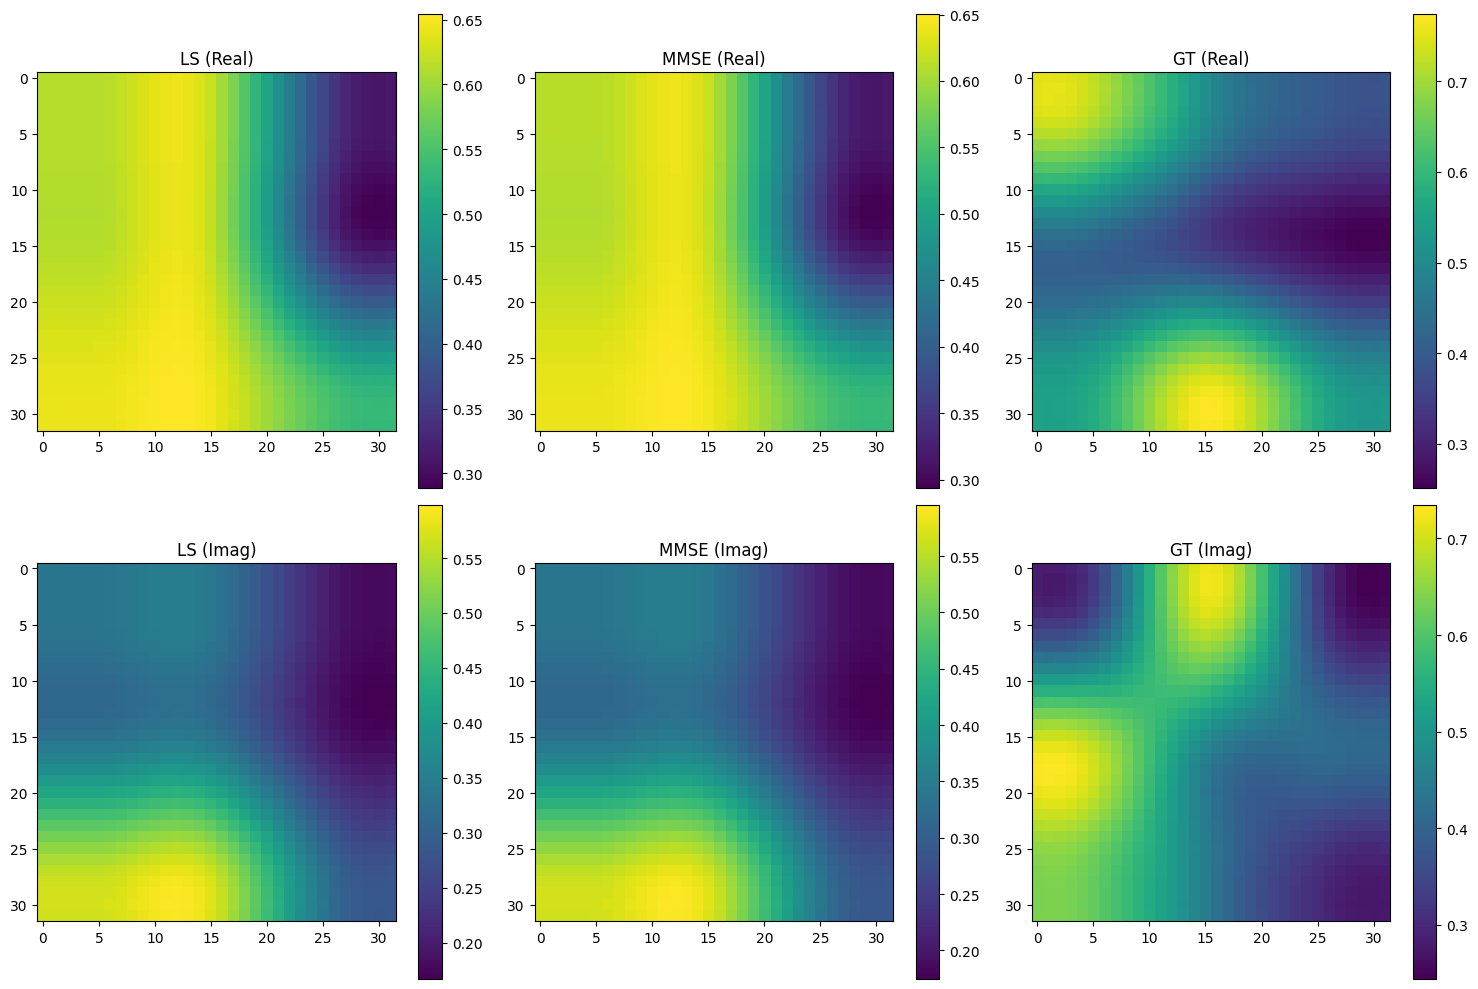

In [ ]:
import cv2

# Target image size (32 x 32) for CNN processing
image_size = (32, 32)

# Initialize arrays for LS, MMSE, and Ground Truth images
X_LS_images = np.zeros((num_samples, image_size[0], image_size[1], 2), dtype=np.float32)
X_MMSE_images = np.zeros((num_samples, image_size[0], image_size[1], 2), dtype=np.float32)
Y_images    = np.zeros((num_samples, image_size[0], image_size[1], 2), dtype=np.float32)     # for GT

# Compute global min and max for real and imaginary parts across all methods
global_min_real = min(np.min(np.real(H_LS_estimated)),
                      np.min(np.real(H_MMSE_estimated)),
                      np.min(np.real(H_ground_truth)))
global_max_real = max(np.max(np.real(H_LS_estimated)),
                      np.max(np.real(H_MMSE_estimated)),
                      np.max(np.real(H_ground_truth)))
global_min_imag = min(np.min(np.imag(H_LS_estimated)),
                      np.min(np.imag(H_MMSE_estimated)),
                      np.min(np.imag(H_ground_truth)))
global_max_imag = max(np.max(np.imag(H_LS_estimated)),
                      np.max(np.imag(H_MMSE_estimated)),
                      np.max(np.imag(H_ground_truth)))

def preprocess_csi(H, global_min_real, global_max_real, global_min_imag, global_max_imag):
    """Resize and normalize a CSI matrix into a two-channel image."""
    H_real = np.real(H)
    H_imag = np.imag(H)
    H_real_resized = cv2.resize(H_real, image_size, interpolation=cv2.INTER_CUBIC)
    H_imag_resized = cv2.resize(H_imag, image_size, interpolation=cv2.INTER_CUBIC)
    H_real_norm = (H_real_resized - global_min_real) / (global_max_real - global_min_real)
    H_imag_norm = (H_imag_resized - global_min_imag) / (global_max_imag - global_min_imag)
    return np.stack([H_real_norm, H_imag_norm], axis=-1)

# Process each sample
for i in range(num_samples):
    X_LS_images[i] = preprocess_csi(H_LS_estimated[i], global_min_real, global_max_real, global_min_imag, global_max_imag)
    X_MMSE_images[i] = preprocess_csi(H_MMSE_estimated[i], global_min_real, global_max_real, global_min_imag, global_max_imag)
    Y_images[i]    = preprocess_csi(H_ground_truth[i], global_min_real, global_max_real, global_min_imag, global_max_imag)

print("✅ Preprocessing complete.")
print("LS Images shape:", X_LS_images.shape)
print("MMSE Images shape:", X_MMSE_images.shape)
print("Ground Truth Images shape:", Y_images.shape)

# Optional: Visualize one sample of each
sample_idx = 0
plt.figure(figsize=(15, 10))
plt.subplot(2,3,1)
plt.imshow(X_LS_images[sample_idx, :, :, 0], cmap='viridis')
plt.title('LS (Real)')
plt.colorbar()
plt.subplot(2,3,2)
plt.imshow(X_MMSE_images[sample_idx, :, :, 0], cmap='viridis')
plt.title('MMSE (Real)')
plt.colorbar()
plt.subplot(2,3,3)
plt.imshow(Y_images[sample_idx, :, :, 0], cmap='viridis')
plt.title('GT (Real)')
plt.colorbar()
plt.subplot(2,3,4)
plt.imshow(X_LS_images[sample_idx, :, :, 1], cmap='viridis')
plt.title('LS (Imag)')
plt.colorbar()
plt.subplot(2,3,5)
plt.imshow(X_MMSE_images[sample_idx, :, :, 1], cmap='viridis')
plt.title('MMSE (Imag)')
plt.colorbar()
plt.subplot(2,3,6)
plt.imshow(Y_images[sample_idx, :, :, 1], cmap='viridis')
plt.title('GT (Imag)')
plt.colorbar()
plt.tight_layout()
plt.show()


STEP 3 : SPLITING DATASET INTO TRAINING AND TESTING



*   The CSI matrices are further divided into training and testing sets
*   Total of 20,000 samples were generated --> 80%(16000) for training and 20%(4000) for testing
*   Both the LS Estimated and MMSE Estimated CSI matrices are splitted






In [ ]:
from sklearn.model_selection import train_test_split

# Split LS images (inputs) and Ground Truth images (labels) into training and testing sets (80:20 split)
X_train, X_test, Y_train, Y_test = train_test_split(X_LS_images, Y_images, test_size=0.2, random_state=42)

#Split MMSE images for comparison
MMSE_train, MMSE_test, _, _ = train_test_split(X_MMSE_images, Y_images, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Input shape:", X_train.shape[1:])  # Should be (32, 32, 2)
print("Output shape:", Y_train.shape[1:])  # Should be (32, 32, 2)


Training samples: 16000
Testing samples: 4000
Input shape: (32, 32, 2)
Output shape: (32, 32, 2)


This is the library which is required for integration of Hyperparameter tuning


In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.3 MB/s eta 0:00:00


STEP 4 : DEFINING THE CNN + AM MODEL

First we are defining the CNN + AM Model which is one of the deep learning models we are using for the CSI Estimation

*  Convolutional Neural Networks (CNN) are employed to treat CSI matrices as image-like inputs. CNN layers are effective in capturing local spatial patterns such as antenna correlations and fading characteristics.

*   A channel-wise Attention Mechanism (AM) is integrated after the CNN layers to help the model selectively focus on the most informative features. This improves learning efficiency and robustness, especially in noisy UV environments.



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != x.shape[-1]:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            shape=(input_shape[-1],),
            initializer='random_normal',
            trainable=True,
            name='attention_weights'
        )

    def call(self, inputs):
        attention_scores = tf.nn.softmax(self.attention_weights)
        attention_scores = tf.reshape(attention_scores, [1, 1, 1, -1])
        return inputs * attention_scores

def build_model_cnn_am(hp):
    # Hyperparameters for CNN+AM variant
    conv1_filters = hp.Int('conv1_filters', min_value=32, max_value=64, step=16, default=64)
    conv2_filters = hp.Int('conv2_filters', min_value=64, max_value=128, step=32, default=128)
    dropout_rate  = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4], default=1e-4)

    inputs = keras.Input(shape=(32, 32, 2))
    x = layers.GaussianNoise(0.1)(inputs)

    # Residual blocks
    x = residual_block(x, filters=conv1_filters)
    x = residual_block(x, filters=conv2_filters)
    x = layers.MaxPooling2D((2,2))(x)

    # Dropout and Attention
    x = layers.Dropout(dropout_rate)(x)
    x = AttentionLayer()(x)

    # Deep Feature Refinement
    x = residual_block(x, filters=128)
    x = residual_block(x, filters=128)

    # Upsample and final convolutional layers
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Conv2D(2, (1,1), activation='linear', padding='same')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=complex_loss, metrics=['mae'])
    return model

#  complex loss function
def complex_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    y_true_mag = tf.sqrt(tf.square(y_true[:,:,:,0]) + tf.square(y_true[:,:,:,1]))
    y_pred_mag = tf.sqrt(tf.square(y_pred[:,:,:,0]) + tf.square(y_pred[:,:,:,1]))
    y_true_mag = tf.expand_dims(y_true_mag, -1)
    y_pred_mag = tf.expand_dims(y_pred_mag, -1)
    ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(y_true_mag, y_pred_mag, max_val=1.0))
    return mse + 0.5 * ssim_loss

# Test the model build
print("CNN+AM Model (Without Transformer):")
model_cnn_am = build_model_cnn_am(kt.HyperParameters())
model_cnn_am.summary()


CNN+AM Model (Without Transformer):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 32, 32, 2)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gaussian_noise            │ (None, 32, 32, 2)      │              0 │ input_layer[0][0]      │
│ (GaussianNoise)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 32, 32, 64)     │          1,216 │ gaussian_noise[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 32, 32, 64)     │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 32, 32, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 64)     │            192 │ gaussian_noise[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
│                           │                        │                │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 32, 32, 64)     │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 128)    │         73,856 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 32, 32, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 32, 32, 128)    │            512 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 128)    │          8,320 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 32, 32, 128)    │              0 │ batch_normalization_3… │
│                           │                        │                │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 32, 32, 128)    │              0 │ add_1[0][0]            │
├──────────────────────

 Total params: 936,322 (3.57 MB)

 Trainable params: 934,402 (3.56 MB)

 Non-trainable params: 1,920 (7.50 KB)

STEP 5 : DEFINING THE CNN + AM + TRANSFORMER MODEL



*  While CNNs focus on local spatial patterns, they lack the ability to learn relationships across distant regions of the CSI matrix. The Transformer solves this by enabling self-attention across all spatial positions, making the model highly effective in identifying long-range dependencies within the CSI structure.



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# -----------------------------
# Residual Block
# -----------------------------
def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != x.shape[-1]:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

# -----------------------------
# Attention Layer
# -----------------------------
class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            shape=(input_shape[-1],),
            initializer='random_normal',
            trainable=True,
            name='attention_weights'
        )

    def call(self, inputs):
        attention_scores = tf.nn.softmax(self.attention_weights)
        attention_scores = tf.reshape(attention_scores, [1, 1, 1, -1])
        return inputs * attention_scores

# -----------------------------
# Positional Encoding for 2D Inputs
# -----------------------------
class PositionalEncoding2D(layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.proj = layers.Dense(channels)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        h, w, c = inputs.shape[1], inputs.shape[2], inputs.shape[3]
        y_pos = tf.range(h, dtype=tf.float32)[:, tf.newaxis]
        x_pos = tf.range(w, dtype=tf.float32)[tf.newaxis, :]
        y_pos = tf.tile(y_pos, [1, w])
        x_pos = tf.tile(x_pos, [h, 1])
        y_pos = tf.expand_dims(y_pos, -1)
        x_pos = tf.expand_dims(x_pos, -1)
        pos = tf.concat([y_pos, x_pos], axis=-1)
        pos = tf.expand_dims(pos, 0)
        pos = tf.tile(pos, [batch_size, 1, 1, 1])
        pos = self.proj(pos)
        return inputs + pos

# -----------------------------
# Transformer Block with Positional Encoding
# -----------------------------
def transformer_block_with_pe(x, num_heads=4, ff_dim=128):
    # Assumes a fixed shape at this stage: (batch, h, w, c)
    _, h, w, c = x.shape
    x = PositionalEncoding2D(channels=c)(x)
    x_flat = layers.Reshape((h * w, c))(x)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=c)(x_flat, x_flat)
    x = layers.Add()([x_flat, attn_output])
    x = layers.LayerNormalization()(x)
    ffn_output = layers.Dense(ff_dim, activation='relu')(x)
    ffn_output = layers.Dense(c)(ffn_output)
    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization()(x)
    return layers.Reshape((h, w, c))(x)

# -----------------------------
# Custom Complex Loss Function
# -----------------------------
def complex_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    y_true_mag = tf.sqrt(tf.square(y_true[:,:,:,0]) + tf.square(y_true[:,:,:,1]))
    y_pred_mag = tf.sqrt(tf.square(y_pred[:,:,:,0]) + tf.square(y_pred[:,:,:,1]))
    y_true_mag = tf.expand_dims(y_true_mag, -1)
    y_pred_mag = tf.expand_dims(y_pred_mag, -1)
    ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(y_true_mag, y_pred_mag, max_val=1.0))
    return mse + 0.5 * ssim_loss

# -----------------------------
# Build Model Function: CNN+AM+Transformer
# -----------------------------
def build_model_cnn_am_trans(hp):
    """
    Build a CNN+AM+Transformer model. All hyperparameters are registered via hp.
    """
    # Register hyperparameters
    conv1_filters = hp.Int('conv1_filters', min_value=32, max_value=64, step=16, default=64)
    conv2_filters = hp.Int('conv2_filters', min_value=64, max_value=128, step=32, default=128)
    dropout_rate  = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4], default=1e-4)
    # Additional transformer hyperparameters:
    num_heads = hp.Int('num_heads', min_value=2, max_value=8, step=2, default=4)
    ff_dim    = hp.Int('ff_dim', min_value=64, max_value=256, step=64, default=128)

    inputs = keras.Input(shape=(32, 32, 2))
    x = layers.GaussianNoise(0.1)(inputs)
    # Residual Blocks
    x = residual_block(x, filters=conv1_filters)
    x = residual_block(x, filters=conv2_filters)
    x = layers.MaxPooling2D((2,2))(x)
    # Dropout and Attention Layer
    x = layers.Dropout(dropout_rate)(x)
    x = AttentionLayer()(x)
    # Transformer block with positional encoding and extra parameters
    x = transformer_block_with_pe(x, num_heads=num_heads, ff_dim=ff_dim)
    # Deep Feature Refinement
    x = residual_block(x, filters=128)
    x = residual_block(x, filters=128)
    # Upsample and final layers
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Conv2D(2, (1,1), activation='linear', padding='same')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=complex_loss, metrics=['mae'])
    return model

# Test the model build and print summary
print("CNN+AM+Transformer Model:")
model_cnn_am_trans = build_model_cnn_am_trans(kt.HyperParameters())
model_cnn_am_trans.summary()


CNN+AM+Transformer Model:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 32, 32, 2)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gaussian_noise_1          │ (None, 32, 32, 2)      │              0 │ input_layer_1[0][0]    │
│ (GaussianNoise)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 32, 32, 64)     │          1,216 │ gaussian_noise_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 32, 32, 64)     │            256 │ conv2d_12[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_10    │ (None, 32, 32, 64)     │            256 │ conv2d_13[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 32, 32, 64)     │            192 │ gaussian_noise_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
│                           │                        │                │ conv2d_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activation) │ (None, 32, 32, 64)     │              0 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 32, 32, 128)    │         73,856 │ activation_4[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 32, 32, 128)    │            512 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 32, 32, 128)    │        147,584 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_12    │ (None, 32, 32, 128)    │            512 │ conv2d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 32, 32, 128)    │          8,320 │ activation_4[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 32, 32, 128)    │              0 │ batch_normalization_1… │
│                           │                        │                │ conv2d_17[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_5 (Activat

 Total params: 1,234,050 (4.71 MB)

 Trainable params: 1,232,130 (4.70 MB)

 Non-trainable params: 1,920 (7.50 KB)

STEP 6 : HYPERPARAMETER TUNING WITH CNN + AM MODEL

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import shutil

# Clean up previous tuning results for CNN+AM variant
shutil.rmtree('hyper_tuning_dir/CSI_CNN_AM_CNNAM', ignore_errors=True)

tuner_cnn_am = kt.RandomSearch(
    build_model_cnn_am,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='hyper_tuning_dir',
    project_name='CSI_CNN_AM_CNNAM'
)

tuner_cnn_am.search_space_summary()

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

tuner_cnn_am.search(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    verbose=1
)

best_hps_cnn_am = tuner_cnn_am.get_best_hyperparameters(num_trials=1)[0]
print("\nBest Hyperparameters for CNN+AM:")
print(best_hps_cnn_am.values)


Trial 10 Complete [00h 03m 22s]
val_loss: 0.2134600281715393

Best val_loss So Far: 0.21243633329868317
Total elapsed time: 00h 29m 46s

Best Hyperparameters for CNN+AM:
{'conv1_filters': 64, 'conv2_filters': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001}


STEP 7 : HYPERPARAMETER TUNING WITH CNN + AM + TRANS MODEL


In [ ]:
shutil.rmtree('hyper_tuning_dir/CSI_CNN_AM_Trans', ignore_errors=True)

tuner_trans = kt.RandomSearch(
    build_model_cnn_am_trans,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='hyper_tuning_dir',
    project_name='CSI_CNN_AM_Trans'
)

tuner_trans.search_space_summary()

tuner_trans.search(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    verbose=1
)

best_hps_trans = tuner_trans.get_best_hyperparameters(num_trials=1)[0]
print("\nBest Hyperparameters for CNN+AM+Transformer:")
print(best_hps_trans.values)


Trial 10 Complete [00h 04m 11s]
val_loss: 0.2150360345840454

Best val_loss So Far: 0.2117156833410263
Total elapsed time: 00h 40m 04s

Best Hyperparameters for CNN+AM+Transformer:
{'conv1_filters': 64, 'conv2_filters': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'num_heads': 4, 'ff_dim': 256}


STEP 8 : TRAINING WITH CNN +AM MODEL

In [ ]:
# Build the best CNN+AM model using the tuned hyperparameters
best_model_cnn_am = build_model_cnn_am(best_hps_cnn_am)

# Train the model
history_cnn_am = best_model_cnn_am.fit(
    X_train, Y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
test_loss_cnn_am, test_mae_cnn_am = best_model_cnn_am.evaluate(X_test, Y_test)
print(f"[CNN+AM] Test Loss: {test_loss_cnn_am:.4f}, Test MAE: {test_mae_cnn_am:.4f}")


Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.5015 - mae: 0.2464 - val_loss: 0.2763 - val_mae: 0.1155 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2318 - mae: 0.0933 - val_loss: 0.2249 - val_mae: 0.0923 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2240 - mae: 0.0904 - val_loss: 0.2180 - val_mae: 0.0874 - learning_rate: 0.0010
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.2211 - mae: 0.0890 - val_loss: 0.2177 - val_mae: 0.0872 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2183 - mae: 0.0875 - val_loss: 0.2182 - val_mae: 0.0910 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2171 - mae: 0.0876 - val_loss: 0.2166 - val_mae: 0.0862 - learning_rate: 0.0010
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2170 - mae: 0.0867 - val_loss: 0.2161 - val_mae: 0.0865 - learning_rat

STEP 9 : TRAINING WITH CNN +AM +TRANS  MODEL

In [ ]:
# Build the best CNN+AM+Transformer model using its best hyperparameters
best_model_trans = build_model_cnn_am_trans(best_hps_trans)

# Train the transformer model
history_trans = best_model_trans.fit(
    X_train, Y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
test_loss_trans, test_mae_trans = best_model_trans.evaluate(X_test, Y_test)
print(f"[CNN+AM+Transformer] Test Loss: {test_loss_trans:.4f}, Test MAE: {test_mae_trans:.4f}")


Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - loss: 0.5228 - mae: 0.2513 - val_loss: 0.2932 - val_mae: 0.1221 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.2368 - mae: 0.1068 - val_loss: 0.2246 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.2252 - mae: 0.1044 - val_loss: 0.2706 - val_mae: 0.1185 - learning_rate: 0.0010
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.2223 - mae: 0.1035 - val_loss: 0.2425 - val_mae: 0.1107 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.2209 - mae: 0.1030 - val_loss: 0.2274 - val_mae: 0.1034 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.2200 - mae: 0.1020 - val_loss: 0.2233 - val_mae: 0.1019 - learning_rate: 0.0010
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.2180 - mae: 0.0993 - val_loss: 0.2268 - val_mae: 0.0984 - learnin

STEP 10 : TESTING THE MODELS

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


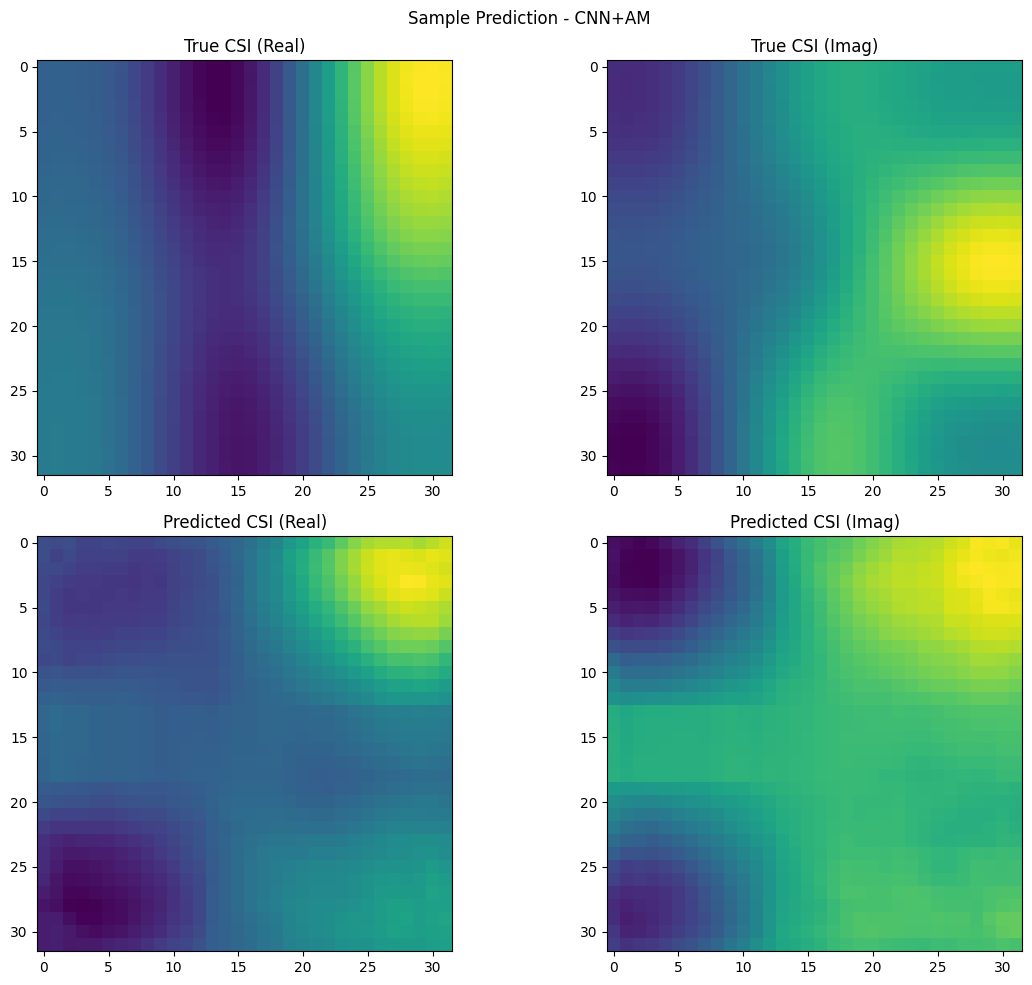

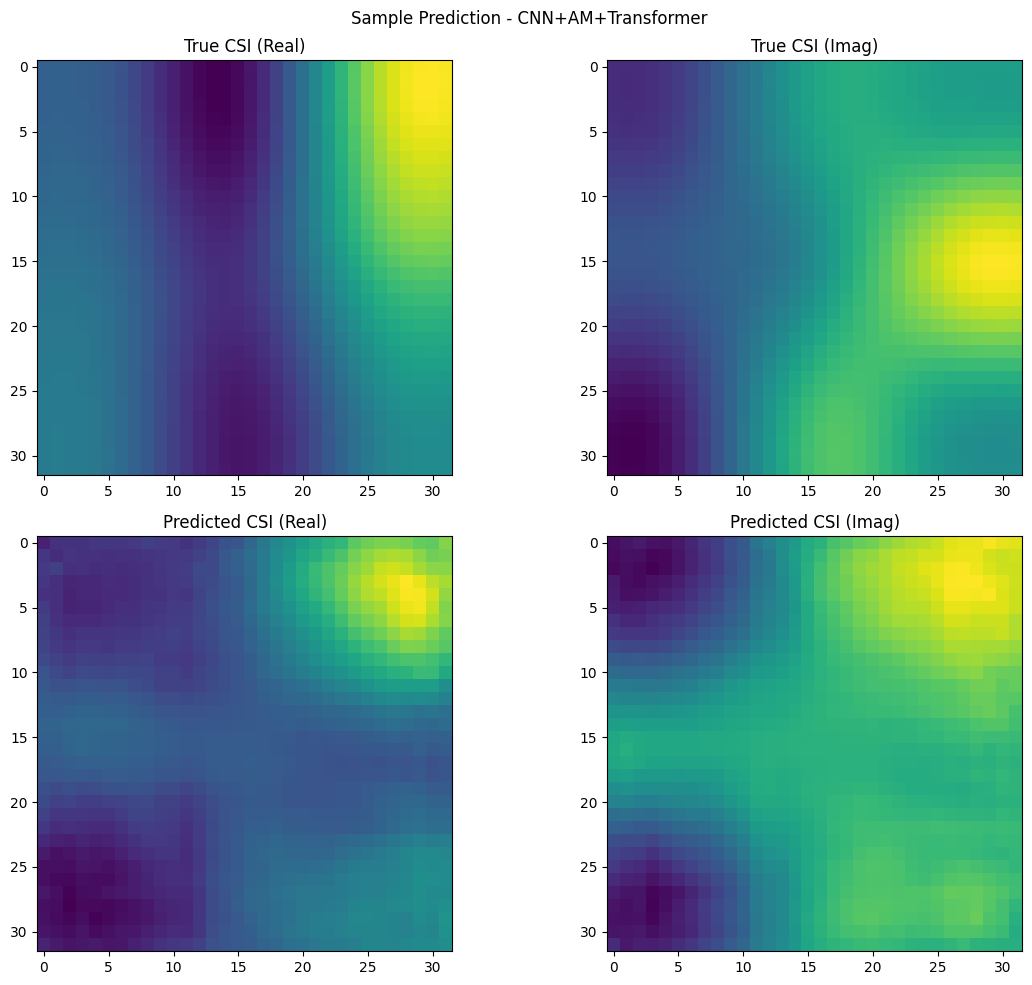


*** LS-Estimated CSI (Baseline) Accuracy Metrics ***
Real Part:  MSE: 0.0229, MAE: 0.1128, SSIM: 47.43%
Imaginary:  MSE: 0.0229, MAE: 0.1131, SSIM: 46.87%
Magnitude:  MSE: 0.0223, MAE: 0.1114, SSIM: 47.79%

*** CNN+AM Accuracy Metrics ***
Real Part:  MSE: 0.0110, MAE: 0.0827, SSIM: 58.73%
Imaginary:  MSE: 0.0110, MAE: 0.0824, SSIM: 58.48%
Magnitude:  MSE: 0.0107, MAE: 0.0815, SSIM: 61.11%

*** CNN+AM+Transformer Accuracy Metrics ***
Real Part:  MSE: 0.0112, MAE: 0.0835, SSIM: 57.39%
Imaginary:  MSE: 0.0111, MAE: 0.0832, SSIM: 57.26%
Magnitude:  MSE: 0.0108, MAE: 0.0822, SSIM: 60.95%


In [ ]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def evaluate_complex_accuracy(y_true, y_pred, method_name):
    mse_real, mae_real, ssim_real = [], [], []
    mse_imag, mae_imag, ssim_imag = [], [], []
    mse_mag, mae_mag, ssim_mag = [], [], []

    for i in range(len(y_true)):
        true_real = y_true[i, :, :, 0]
        pred_real = y_pred[i, :, :, 0]
        true_imag = y_true[i, :, :, 1]
        pred_imag = y_pred[i, :, :, 1]

        true_mag = np.sqrt(true_real**2 + true_imag**2)
        pred_mag = np.sqrt(pred_real**2 + pred_imag**2)

        mse_real.append(np.mean((true_real - pred_real) ** 2))
        mae_real.append(np.mean(np.abs(true_real - pred_real)))
        ssim_real.append(ssim(true_real, pred_real, data_range=true_real.max()-true_real.min(), win_size=3))

        mse_imag.append(np.mean((true_imag - pred_imag) ** 2))
        mae_imag.append(np.mean(np.abs(true_imag - pred_imag)))
        ssim_imag.append(ssim(true_imag, pred_imag, data_range=true_imag.max()-true_imag.min(), win_size=3))

        mse_mag.append(np.mean((true_mag - pred_mag) ** 2))
        mae_mag.append(np.mean(np.abs(true_mag - pred_mag)))
        ssim_mag.append(ssim(true_mag, pred_mag, data_range=true_mag.max()-true_mag.min(), win_size=3))

    print(f"\n*** {method_name} Accuracy Metrics ***")
    print("Real Part:  MSE: {:.4f}, MAE: {:.4f}, SSIM: {:.2f}%".format(np.mean(mse_real),
          np.mean(mae_real), np.mean(ssim_real)*100))
    print("Imaginary:  MSE: {:.4f}, MAE: {:.4f}, SSIM: {:.2f}%".format(np.mean(mse_imag),
          np.mean(mae_imag), np.mean(ssim_imag)*100))
    print("Magnitude:  MSE: {:.4f}, MAE: {:.4f}, SSIM: {:.2f}%".format(np.mean(mse_mag),
          np.mean(mae_mag), np.mean(ssim_mag)*100))

# Generate predictions with LS baseline (i.e., use X_test, which are LS images)
# CNN+AM predictions:
predictions_cnn_am = best_model_cnn_am.predict(X_test)
# CNN+AM+Transformer predictions:
predictions_trans = best_model_trans.predict(X_test)

# Visualize a sample (for example, sample index 0)
sample_idx = np.random.randint(0, len(X_test))
def plot_csi(true_csi, pred_csi, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(true_csi[:,:,0], cmap='viridis'); axes[0, 0].set_title('True CSI (Real)')
    axes[0, 1].imshow(true_csi[:,:,1], cmap='viridis'); axes[0, 1].set_title('True CSI (Imag)')
    axes[1, 0].imshow(pred_csi[:,:,0], cmap='viridis'); axes[1, 0].set_title('Predicted CSI (Real)')
    axes[1, 1].imshow(pred_csi[:,:,1], cmap='viridis'); axes[1, 1].set_title('Predicted CSI (Imag)')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot sample predictions for both models
plot_csi(Y_test[sample_idx], predictions_cnn_am[sample_idx], 'Sample Prediction - CNN+AM')
plot_csi(Y_test[sample_idx], predictions_trans[sample_idx], 'Sample Prediction - CNN+AM+Transformer')

# Evaluate each method
evaluate_complex_accuracy(Y_test, X_test, "LS-Estimated CSI (Baseline)")
evaluate_complex_accuracy(Y_test, predictions_cnn_am, "CNN+AM")
evaluate_complex_accuracy(Y_test, predictions_trans, "CNN+AM+Transformer")
